# Real Estate Investment Advisor

This project aims to develop a machine learning application to assist potential investors in making real estate decisions.

The outcome of the project is to:
* Classify whether a property is a "Good Investment".
* Predict the estimated property price after 5 years.

This notebook shows: 
1. Data Cleaning & Preprcessing 
2. Exploratory Data Analysis & Data Visualization 
3. Feature Engineering 
4. Machine Learning Model Development 
5. Model deployment in Streamlit Web Application


## Importing libraries, datasets and defining utility functions

In [1810]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [1811]:
# Utility Functions

# Percentage of Missing Values
def per_miss_val(df):
  return 100 * df.isnull().sum() / len(df)

In [1812]:
# Read Dataset
df = pd.read_csv('Datasets/india_housing_prices.csv')

# Data Cleaning and Preprocessing for EDA

In [1813]:
# First 5 rows
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [1814]:
# Last 5 Rows
df.tail()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move
249999,250000,Haryana,Gurgaon,Locality_268,Independent House,3,4313,199.69,0.05,1990,...,35,10,6,Medium,No,No,"Gym, Garden",South,Owner,Under_Construction


In [1815]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [1816]:
# Checking for missing/null values in the dataframe
per = per_miss_val(df)
print(per)

ID                                0.0
State                             0.0
City                              0.0
Locality                          0.0
Property_Type                     0.0
BHK                               0.0
Size_in_SqFt                      0.0
Price_in_Lakhs                    0.0
Price_per_SqFt                    0.0
Year_Built                        0.0
Furnished_Status                  0.0
Floor_No                          0.0
Total_Floors                      0.0
Age_of_Property                   0.0
Nearby_Schools                    0.0
Nearby_Hospitals                  0.0
Public_Transport_Accessibility    0.0
Parking_Space                     0.0
Security                          0.0
Amenities                         0.0
Facing                            0.0
Owner_Type                        0.0
Availability_Status               0.0
dtype: float64


No `null` values identified in the data.

### Property Location Columns

In [1817]:
# State Column
print("Property State Stats")
print(df['State'].describe())
print('')
# States Present in the dataset
print(f"States List: {df['State'].unique()}")

Property State Stats
count     250000
unique        20
top       Odisha
freq       12681
Name: State, dtype: object

States List: ['Tamil Nadu' 'Maharashtra' 'Punjab' 'Rajasthan' 'West Bengal'
 'Chhattisgarh' 'Delhi' 'Jharkhand' 'Telangana' 'Karnataka'
 'Uttar Pradesh' 'Assam' 'Uttarakhand' 'Bihar' 'Gujarat' 'Haryana'
 'Andhra Pradesh' 'Madhya Pradesh' 'Kerala' 'Odisha']


In [1818]:
# Checking for datatype consistency
dtypes = list(df['State'].apply(type).unique())
print(f"Datatypes present in State column: {dtypes}")

Datatypes present in State column: [<class 'str'>]


In [1819]:
# City Column
print("Property City Stats")
print(df['City'].describe())
print('')
# Cities Present in the dataset
print(f"City List: {df['City'].unique()}")

Property City Stats
count         250000
unique            42
top       Coimbatore
freq            6461
Name: City, dtype: object

City List: ['Chennai' 'Pune' 'Ludhiana' 'Jodhpur' 'Jaipur' 'Durgapur' 'Coimbatore'
 'Bilaspur' 'New Delhi' 'Ranchi' 'Warangal' 'Bangalore' 'Nagpur' 'Lucknow'
 'Silchar' 'Dehradun' 'Noida' 'Gaya' 'Jamshedpur' 'Ahmedabad' 'Hyderabad'
 'Faridabad' 'Amritsar' 'Kolkata' 'Dwarka' 'Vishakhapatnam' 'Bhopal'
 'Indore' 'Haridwar' 'Mysore' 'Patna' 'Raipur' 'Vijayawada' 'Trivandrum'
 'Kochi' 'Surat' 'Gurgaon' 'Mangalore' 'Cuttack' 'Bhubaneswar' 'Guwahati'
 'Mumbai']


In [1820]:
# Locality Column
print('Property Locality Stats')
print(df['Locality'].describe())
print('')
# List of localities
print("Locality List")
df['Locality'].unique()

Property Locality Stats
count           250000
unique             500
top       Locality_296
freq               567
Name: Locality, dtype: object

Locality List


array(['Locality_84', 'Locality_490', 'Locality_167', 'Locality_393',
       'Locality_466', 'Locality_246', 'Locality_254', 'Locality_232',
       'Locality_122', 'Locality_75', 'Locality_462', 'Locality_227',
       'Locality_287', 'Locality_148', 'Locality_369', 'Locality_265',
       'Locality_50', 'Locality_385', 'Locality_241', 'Locality_286',
       'Locality_74', 'Locality_459', 'Locality_355', 'Locality_151',
       'Locality_159', 'Locality_382', 'Locality_143', 'Locality_454',
       'Locality_262', 'Locality_136', 'Locality_223', 'Locality_368',
       'Locality_480', 'Locality_485', 'Locality_398', 'Locality_305',
       'Locality_114', 'Locality_202', 'Locality_96', 'Locality_295',
       'Locality_58', 'Locality_484', 'Locality_323', 'Locality_432',
       'Locality_273', 'Locality_458', 'Locality_150', 'Locality_238',
       'Locality_494', 'Locality_464', 'Locality_431', 'Locality_125',
       'Locality_218', 'Locality_112', 'Locality_27', 'Locality_40',
       'Locali

In [1821]:
# Replacing Locality data with locality number only
def extract_locality_number(val):
  val_list = val.split("_")
  return int(val_list[1])

df['Locality'] = df['Locality'].apply(lambda x: extract_locality_number(x))
df['Locality']

0          84
1         490
2         167
3         393
4         466
         ... 
249995    187
249996    348
249997    225
249998    138
249999    268
Name: Locality, Length: 250000, dtype: int64

In [1822]:
# Stats about property location
print("Property Location Stats")
df[['State','City','Locality']].describe(include='all')

Property Location Stats


,State,City,Locality
count,250000,250000,250000.000000
unique,20,42,NaN
top,Odisha,Coimbatore,NaN
freq,12681,6461,NaN
mean,NaN,NaN,250.399508
std,NaN,NaN,144.544014
min,NaN,NaN,1.000000
25%,NaN,NaN,125.000000
50%,NaN,NaN,250.000000
75%,NaN,NaN,376.000000


### Property Specifications, Age and Amenities Columns

In [1823]:
# Property Type column
print("Property Type Stats")
print(df['Property_Type'].describe())
print('')
# List of Property Types
print("Property Types: ", df['Property_Type'].unique())

Property Type Stats
count     250000
unique         3
top        Villa
freq       83744
Name: Property_Type, dtype: object

Property Types:  ['Apartment' 'Independent House' 'Villa']


In [1824]:
# Stats about BHK
print("Property BHK stats")
print(df['BHK'].describe())
print('')
print(f"BHK Types: {df['BHK'].unique()}")

Property BHK stats
count    250000.000000
mean          2.999396
std           1.415521
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max           5.000000
Name: BHK, dtype: float64

BHK Types: [1 3 2 4 5]


In [1825]:
# Stats about Sqft
print("Property Size(In Sqft) Stats")
df['Size_in_SqFt'].describe()

Property Size(In Sqft) Stats


count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

In [1826]:
# Stats about Price
print("Property Price(In Lakhs) Stats")
df['Price_in_Lakhs'].describe()

Property Price(In Lakhs) Stats


count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

In [1827]:
# Stats about Price per Sqft
print("Price Per SqFt(In Lakhs) Stats")
df['Price_per_SqFt'].describe()

Price Per SqFt(In Lakhs) Stats


count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
Name: Price_per_SqFt, dtype: float64

Price per sqft cannot be `0` (as shown in the min value).

In [1828]:
# No of rows with Price_Per_SqFt = 0
print(f"No of rows with 0: {len(df[df['Price_per_SqFt'] == 0])}")

No of rows with 0: 2534


Let's calculate the `price_per_sqft` using `Price_In_Lakhs` and `Size_in_SqFt`.

In [1829]:
# Price_Per_SqFt given in the dataset
existing_price_df = df['Price_per_SqFt']

# Calculate Price_Per_SqFt using Size_in_SqFt and Price_in_Lakhs
calculated_price_round_to_2 = ((df['Price_in_Lakhs']) * 100000 / (df['Size_in_SqFt']) / 100000).round(2)

Let's check if the given price and the calculated price are equal.

In [1830]:
# Checking if the existing data and the calculated data are equal to each other
print((calculated_price_round_to_2 == existing_price_df).all())

False


In [1831]:
# Rows that mismatch with the given price and the calculated price
mismatch = calculated_price_round_to_2 != existing_price_df
result = pd.DataFrame({
    'calculated': calculated_price_round_to_2[mismatch],
    'existing': existing_price_df[mismatch]
})
result

,calculated,existing
16607,0.52,0.53
26681,0.52,0.53
30731,0.08,0.07
52600,0.16,0.15
68796,0.14,0.15
74153,0.46,0.45
75443,0.08,0.09
75873,0.02,0.01
85357,0.30,0.29
88087,0.00,0.01


In [1832]:
# Calculated Price_Per_Sqft Stats
calculated_price_round_to_2.describe()

count    250000.000000
mean          0.130597
std           0.130747
min           0.000000
25%           0.050000
50%           0.090000
75%           0.160000
max           0.990000
dtype: float64

The resulting `0` is an artifact of rounding.

Let's try rounding the value to 3

In [1833]:
calculated_price_round_to_3 = ((df['Price_in_Lakhs']) * 100000 / (df['Size_in_SqFt']) / 100000).round(3)

print("Price Per SqFt Rounded to 3 decimal")
calculated_price_round_to_3.describe()

Price Per SqFt Rounded to 3 decimal


count    250000.000000
mean          0.130583
std           0.130719
min           0.002000
25%           0.048000
50%           0.092000
75%           0.160000
max           0.992000
dtype: float64

Let's Check for `0` value rows

In [1834]:
print(f"No of rows with 0: {len(calculated_price_round_to_3[calculated_price_round_to_3 == 0])}")

No of rows with 0: 0


Replacing the existing `Price_per_SqFt` with `calculated_price_round_to_3` values, rounded to 3.

In [1835]:
df['Price_per_SqFt'] = calculated_price_round_to_3
df['Price_per_SqFt']

0         0.103
1         0.083
2         0.050
3         0.110
4         0.038
          ...  
249995    0.138
249996    0.006
249997    0.081
249998    0.123
249999    0.046
Name: Price_per_SqFt, Length: 250000, dtype: float64

In [1836]:
# Year Built Stats
print("Property year built stats")
print(df['Year_Built'].describe())

Property year built stats
count    250000.000000
mean       2006.520012
std           9.808575
min        1990.000000
25%        1998.000000
50%        2007.000000
75%        2015.000000
max        2023.000000
Name: Year_Built, dtype: float64


In [1837]:
# Furnish Status Stats
print("Property Furnish Status Stats")
print(df['Furnished_Status'].describe())

print("")
print(f"Furnishing Status: {df['Furnished_Status'].unique()}")

Property Furnish Status Stats
count          250000
unique              3
top       Unfurnished
freq            83408
Name: Furnished_Status, dtype: object

Furnishing Status: ['Furnished' 'Unfurnished' 'Semi-furnished']


In [1838]:
# Floor Number Stats
print("Property Floor Number Stats")
print(df['Floor_No'].describe())

Property Floor Number Stats
count    250000.000000
mean         14.966800
std           8.948047
min           0.000000
25%           7.000000
50%          15.000000
75%          23.000000
max          30.000000
Name: Floor_No, dtype: float64


In [1839]:
# Total Floors Stats
print("Property Total Floors Stats")
print(df['Total_Floors'].describe())

Property Total Floors Stats
count    250000.000000
mean         15.503004
std           8.671618
min           1.000000
25%           8.000000
50%          15.000000
75%          23.000000
max          30.000000
Name: Total_Floors, dtype: float64


In [1840]:
# Age of Property Stats
print("Property Age Stats")
print(df['Age_of_Property'].describe())

Property Age Stats
count    250000.000000
mean         18.479988
std           9.808575
min           2.000000
25%          10.000000
50%          18.000000
75%          27.000000
max          35.000000
Name: Age_of_Property, dtype: float64


In [1841]:
# Nearby Schools Stats
print('Schools Nearby the Property Stats')
df['Nearby_Schools'].describe()

Schools Nearby the Property Stats


count    250000.000000
mean          5.499860
std           2.878639
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: Nearby_Schools, dtype: float64

In [1842]:
# Nearby Hospitals Stats
print("Hospitals Nearby the Property Stats")
df['Nearby_Hospitals'].describe()

Hospitals Nearby the Property Stats


count    250000.000000
mean          5.498016
std           2.871860
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          10.000000
Name: Nearby_Hospitals, dtype: float64

In [1843]:
# Public Transport Availability Stats
print("Public Transport Availability Stats")
print(df['Public_Transport_Accessibility'].describe())
print("")
print(f'Availability Values : {df['Public_Transport_Accessibility'].unique()}')

Public Transport Availability Stats
count     250000
unique         3
top         High
freq       83705
Name: Public_Transport_Accessibility, dtype: object

Availability Values : ['High' 'Low' 'Medium']


In [1844]:
# Parking Space Stats
print("Parking Space Stats")
print(df['Parking_Space'].describe())
print("")
print(f'Values: {df['Parking_Space'].unique()}')

Parking Space Stats


count     250000
unique         2
top           No
freq      125456
Name: Parking_Space, dtype: object

Values: ['No' 'Yes']


In [1845]:
# Property Security Stats
print('Property Security Stats')
print(df['Security'].describe())
print("")

print(f'Values: {df['Security'].unique()}')

Property Security Stats
count     250000
unique         2
top          Yes
freq      125233
Name: Security, dtype: object

Values: ['No' 'Yes']


In [1846]:
# Amenities Stats
print('Property Amenities Stats')
print(df['Amenities'].describe())

Property Amenities Stats
count     250000
unique       325
top         Pool
freq       10218
Name: Amenities, dtype: object


In [1847]:
# Reading the Amenities Column
df['Amenities']

0         Playground, Gym, Garden, Pool, Clubhouse
1         Playground, Clubhouse, Pool, Gym, Garden
2                 Clubhouse, Pool, Playground, Gym
3         Playground, Clubhouse, Gym, Pool, Garden
4         Playground, Garden, Gym, Pool, Clubhouse
                            ...                   
249995    Playground, Garden, Gym, Clubhouse, Pool
249996                                  Playground
249997                                  Playground
249998                       Playground, Gym, Pool
249999                                 Gym, Garden
Name: Amenities, Length: 250000, dtype: object

`Amenities` column holds multi-label categorical values.

Let's split and encode each amenity into its own column.

In [1848]:
# Splitting, encoding each amenity and removing amenities column from dataframe
df_amenities = df['Amenities'].str.get_dummies(sep=', ')
df_amenities = df_amenities.replace({1: 'Yes', 0: 'No'})
df = pd.concat([df, df_amenities], axis=1)
df = df.drop('Amenities', axis=1)
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Parking_Space,Security,Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,84,Apartment,1,4740,489.76,0.103,1990,...,No,No,West,Owner,Ready_to_Move,Yes,Yes,Yes,Yes,Yes
1,2,Maharashtra,Pune,490,Independent House,3,2364,195.52,0.083,2008,...,No,Yes,North,Builder,Under_Construction,Yes,Yes,Yes,Yes,Yes
2,3,Punjab,Ludhiana,167,Apartment,2,3642,183.79,0.050,1997,...,Yes,No,South,Broker,Ready_to_Move,Yes,No,Yes,Yes,Yes
3,4,Rajasthan,Jodhpur,393,Independent House,2,2741,300.29,0.110,1991,...,Yes,Yes,North,Builder,Ready_to_Move,Yes,Yes,Yes,Yes,Yes
4,5,Rajasthan,Jaipur,466,Villa,4,4823,182.90,0.038,2002,...,No,Yes,East,Builder,Ready_to_Move,Yes,Yes,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,187,Independent House,5,1995,274.75,0.138,1995,...,No,No,East,Broker,Under_Construction,Yes,Yes,Yes,Yes,Yes
249996,249997,Tamil Nadu,Chennai,348,Apartment,1,2293,13.40,0.006,2013,...,No,No,South,Broker,Ready_to_Move,No,No,No,Yes,No
249997,249998,Telangana,Warangal,225,Villa,4,2910,236.94,0.081,2003,...,Yes,Yes,South,Builder,Under_Construction,No,No,No,Yes,No
249998,249999,Odisha,Cuttack,138,Villa,1,1149,141.66,0.123,2007,...,Yes,Yes,South,Owner,Ready_to_Move,No,No,Yes,Yes,Yes


In [1849]:
# Facing Stats
print("Property Facing Stats")
print(df['Facing'].describe())
print("")
print(f"Values: {df['Facing'].unique()}")

Property Facing Stats
count     250000
unique         4
top         West
freq       62757
Name: Facing, dtype: object

Values: ['West' 'North' 'South' 'East']


In [1850]:
# Owner Type Stats
print("Property Owner Type Stats")
print(df['Owner_Type'].describe())
print("")
print(f"Unique Values: {df['Owner_Type'].unique()}")

Property Owner Type Stats
count     250000
unique         3
top       Broker
freq       83479
Name: Owner_Type, dtype: object

Unique Values: ['Owner' 'Builder' 'Broker']


In [1851]:
# Property Availability Stats
print("Property Availability Stats")
print(df['Availability_Status'].describe())
print("")
print(f'Values: {df['Availability_Status'].unique()}')

Property Availability Stats
count                 250000
unique                     2
top       Under_Construction
freq                  125035
Name: Availability_Status, dtype: object

Values: ['Ready_to_Move' 'Under_Construction']


In [1852]:
# Replacing availability values with Yes/No
df['Availability_Status'] = df['Availability_Status'].replace({'Ready_to_Move':'Yes', 'Under_Construction': 'No'})
print(f'Property Availability Values : {df['Availability_Status'].unique()}')

Property Availability Values : ['Yes' 'No']


In [1853]:
# Renaming Columns
df.rename(columns={'Nearby_Schools':'Total_Nearby_Schools', 'Nearby_Hospitals': 'Total_Nearby_Hospitals', 'Price_per_SqFt': 'Price_per_SqFt_in_Lakhs', 'Facing':'Direction_Facing'}, inplace=True)
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt_in_Lakhs,Year_Built,...,Parking_Space,Security,Direction_Facing,Owner_Type,Availability_Status,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,84,Apartment,1,4740,489.76,0.103,1990,...,No,No,West,Owner,Yes,Yes,Yes,Yes,Yes,Yes
1,2,Maharashtra,Pune,490,Independent House,3,2364,195.52,0.083,2008,...,No,Yes,North,Builder,No,Yes,Yes,Yes,Yes,Yes
2,3,Punjab,Ludhiana,167,Apartment,2,3642,183.79,0.050,1997,...,Yes,No,South,Broker,Yes,Yes,No,Yes,Yes,Yes
3,4,Rajasthan,Jodhpur,393,Independent House,2,2741,300.29,0.110,1991,...,Yes,Yes,North,Builder,Yes,Yes,Yes,Yes,Yes,Yes
4,5,Rajasthan,Jaipur,466,Villa,4,4823,182.90,0.038,2002,...,No,Yes,East,Builder,Yes,Yes,Yes,Yes,Yes,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,187,Independent House,5,1995,274.75,0.138,1995,...,No,No,East,Broker,No,Yes,Yes,Yes,Yes,Yes
249996,249997,Tamil Nadu,Chennai,348,Apartment,1,2293,13.40,0.006,2013,...,No,No,South,Broker,Yes,No,No,No,Yes,No
249997,249998,Telangana,Warangal,225,Villa,4,2910,236.94,0.081,2003,...,Yes,Yes,South,Builder,No,No,No,No,Yes,No
249998,249999,Odisha,Cuttack,138,Villa,1,1149,141.66,0.123,2007,...,Yes,Yes,South,Owner,Yes,No,No,Yes,Yes,Yes


In [1854]:
# Rearranging columns for better associations
df = df[['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_per_SqFt_in_Lakhs', 'Price_in_Lakhs', 'Year_Built', 'Furnished_Status', 'Direction_Facing', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Owner_Type', 'Availability_Status', 'Total_Nearby_Schools', 'Total_Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Clubhouse', 'Garden', 'Gym', 'Playground', 'Pool']]
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Total_Nearby_Schools,Total_Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool
0,1,Tamil Nadu,Chennai,84,Apartment,1,4740,0.103,489.76,1990,...,10,3,High,No,No,Yes,Yes,Yes,Yes,Yes
1,2,Maharashtra,Pune,490,Independent House,3,2364,0.083,195.52,2008,...,8,1,Low,No,Yes,Yes,Yes,Yes,Yes,Yes
2,3,Punjab,Ludhiana,167,Apartment,2,3642,0.050,183.79,1997,...,9,8,Low,Yes,No,Yes,No,Yes,Yes,Yes
3,4,Rajasthan,Jodhpur,393,Independent House,2,2741,0.110,300.29,1991,...,5,7,High,Yes,Yes,Yes,Yes,Yes,Yes,Yes
4,5,Rajasthan,Jaipur,466,Villa,4,4823,0.038,182.90,2002,...,4,9,Low,No,Yes,Yes,Yes,Yes,Yes,Yes


In [1855]:
# Final Dataset information for EDA
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  int64  
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_per_SqFt_in_Lakhs         250000 non-null  float64
 8   Price_in_Lakhs                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Direction_Facing                250000 non-null  object 
 12  Floor_No        

In [1856]:
# Final Stats
df.describe(include='all')

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_per_SqFt_in_Lakhs,Price_in_Lakhs,Year_Built,...,Total_Nearby_Schools,Total_Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Clubhouse,Garden,Gym,Playground,Pool
count,250000.000000,250000,250000,250000.000000,250000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,...,250000.000000,250000.000000,250000,250000,250000,250000,250000,250000,250000,250000
unique,NaN,20,42,NaN,3,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3,2,2,2,2,2,2,2
top,NaN,Odisha,Coimbatore,NaN,Villa,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,High,No,Yes,Yes,Yes,Yes,Yes,Yes
freq,NaN,12681,6461,NaN,83744,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,83705,125456,125233,150059,150177,149960,149780,150096
mean,125000.500000,NaN,NaN,250.399508,NaN,2.999396,2749.813216,0.130583,254.586854,2006.520012,...,5.499860,5.498016,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,72168.927986,NaN,NaN,144.544014,NaN,1.415521,1300.606954,0.130719,141.349921,9.808575,...,2.878639,2.871860,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,1.000000,NaN,1.000000,500.000000,0.002000,10.000000,1990.000000,...,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,62500.750000,NaN,NaN,125.000000,NaN,2.000000,1623.000000,0.048000,132.550000,1998.000000,...,3.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,125000.500000,NaN,NaN,250.000000,NaN,3.000000,2747.000000,0.092000,253.870000,2007.000000,...,5.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,187500.250000,NaN,NaN,376.000000,NaN,4.000000,3874.000000,0.160000,376.880000,2015.000000,...,8.000000,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **Exploratory Data Analysis**

## 1. Price and Size Analysis (1-5)

### 1.1 Property Price Distribution

In [1857]:
df['Price_in_Lakhs'].describe()

count    250000.000000
mean        254.586854
std         141.349921
min          10.000000
25%         132.550000
50%         253.870000
75%         376.880000
max         500.000000
Name: Price_in_Lakhs, dtype: float64

In [1858]:
# Creating a Price Bucket
my_price_bucket = pd.Series()
my_price_bucket['0 to 50L'] = len(df[df['Price_in_Lakhs'] < 50][df['Price_in_Lakhs'] >=0])
my_price_bucket['50L to 1Cr'] = len(df[df['Price_in_Lakhs'] < 100][df['Price_in_Lakhs'] >=50])
my_price_bucket['1Cr to 1.5Cr'] = len(df[df['Price_in_Lakhs'] < 150][df['Price_in_Lakhs'] >=100])
my_price_bucket['1.5Cr to 2Cr'] = len(df[df['Price_in_Lakhs'] < 200][df['Price_in_Lakhs'] >=150])
my_price_bucket['2Cr to 2.5 Cr'] = len(df[df['Price_in_Lakhs'] < 250][df['Price_in_Lakhs'] >=200])
my_price_bucket['2.5Cr to 3Cr'] = len(df[df['Price_in_Lakhs'] < 300][df['Price_in_Lakhs'] >=250])
my_price_bucket['3Cr to 3.5Cr'] = len(df[df['Price_in_Lakhs'] < 350][df['Price_in_Lakhs'] >=300])
my_price_bucket['3.5Cr to 4Cr'] = len(df[df['Price_in_Lakhs'] < 400][df['Price_in_Lakhs'] >=350])
my_price_bucket['4Cr to 4.5 Cr'] = len(df[df['Price_in_Lakhs'] < 450][df['Price_in_Lakhs'] >=400])
my_price_bucket['4.5Cr to 5Cr'] = len(df[df['Price_in_Lakhs'] < 500][df['Price_in_Lakhs'] >=450])

my_price_bucket

0 to 50L         20304
50L to 1Cr       25431
1Cr to 1.5Cr     25823
1.5Cr to 2Cr     25958
2Cr to 2.5 Cr    25602
2.5Cr to 3Cr     25257
3Cr to 3.5Cr     25503
3.5Cr to 4Cr     25254
4Cr to 4.5 Cr    25259
4.5Cr to 5Cr     25608
dtype: int64

In [1859]:
# Alternate version (Recommended Approach)
bins = [0, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, np.inf]
labels = ['0 to 50L', '50L to 1Cr', '1Cr to 1.5Cr', '1.5Cr to 2Cr', '2Cr to 2.5 Cr', '2.5Cr to 3Cr', '3Cr to 3.5Cr', '3.5Cr to 4Cr', '4Cr to 4.5 Cr', '4.5Cr to 5Cr', '5Cr and more']
price_bucket = pd.cut(df['Price_in_Lakhs'], bins=bins, labels=labels) # (left, right]
price_bucket_counts = price_bucket.value_counts().sort_index()
print("Property Price Distribution")
price_bucket_counts

Property Price Distribution


Price_in_Lakhs
0 to 50L         20307
50L to 1Cr       25432
1Cr to 1.5Cr     25824
1.5Cr to 2Cr     25954
2Cr to 2.5 Cr    25604
2.5Cr to 3Cr     25260
3Cr to 3.5Cr     25502
3.5Cr to 4Cr     25252
4Cr to 4.5 Cr    25263
4.5Cr to 5Cr     25602
5Cr and more         0
Name: count, dtype: int64

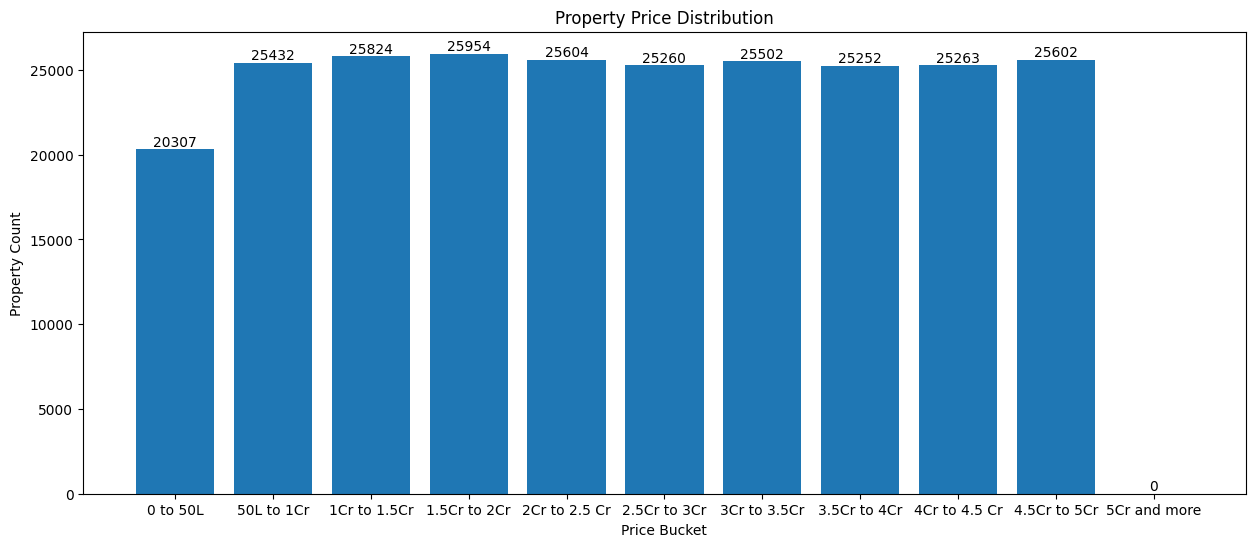

In [1860]:
# Visualization
plt.figure(figsize=(15,6))
plt.bar(price_bucket_counts.index, price_bucket_counts.values)

for index, value in zip(price_bucket_counts.index, price_bucket_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Property Price Distribution")
plt.xlabel("Price Bucket")
plt.ylabel("Property Count")
plt.show()

### 1.2 Property Size Distribution

In [1861]:
df['Size_in_SqFt'].describe()

count    250000.000000
mean       2749.813216
std        1300.606954
min         500.000000
25%        1623.000000
50%        2747.000000
75%        3874.000000
max        5000.000000
Name: Size_in_SqFt, dtype: float64

In [1862]:
# Creating Size bucket
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, np.inf]
labels = ['0 to 500', '500 to 1000', '1000 to 1500', '1500 to 2000', '2000 to 2500', '2500 to 3000', '3000 to 3500', '3500 to 4000', '4000 to 4500', '4500 to 5000', '5000 and above']
size_bucket = pd.cut(df['Size_in_SqFt'], bins=bins, labels=labels)
size_bucket_counts = size_bucket.value_counts().sort_index()
print("Property Size Distribution")
size_bucket_counts

Property Size Distribution


Size_in_SqFt
0 to 500             57
500 to 1000       27940
1000 to 1500      27644
1500 to 2000      27682
2000 to 2500      27838
2500 to 3000      27826
3000 to 3500      27686
3500 to 4000      27766
4000 to 4500      27591
4500 to 5000      27970
5000 and above        0
Name: count, dtype: int64

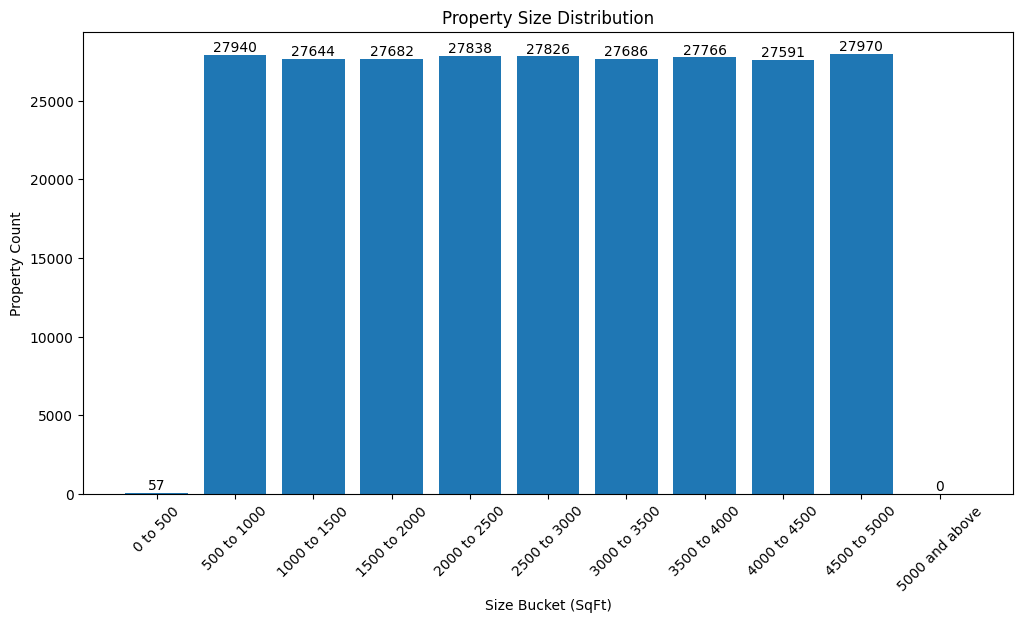

In [1863]:
# Visualization
plt.figure(figsize=(12, 6))
plt.bar(size_bucket_counts.index, size_bucket_counts.values)

for index, value in zip(size_bucket_counts.index, size_bucket_counts.values):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title("Property Size Distribution")
plt.xlabel("Size Bucket (SqFt)")
plt.ylabel("Property Count")
plt.show()

### 1.3 Price per Sqft based on Property Type

In [1864]:
df[['Property_Type', 'Price_per_SqFt_in_Lakhs']]

,Property_Type,Price_per_SqFt_in_Lakhs
0,Apartment,0.103
1,Independent House,0.083
2,Apartment,0.050
3,Independent House,0.110
4,Villa,0.038
...,...,...
249995,Independent House,0.138
249996,Apartment,0.006
249997,Villa,0.081
249998,Villa,0.123


In [1865]:
# Stats for Price Per SqFt Based on Property Type
price_per_sqft_on_type = df.groupby('Property_Type')['Price_per_SqFt_in_Lakhs'].agg(['mean', 'median', 'count']).reset_index().sort_values('mean')
price_per_sqft_on_type['mean'] = price_per_sqft_on_type['mean'].round(6) * 100000
price_per_sqft_on_type['median'] = price_per_sqft_on_type['median'].round(6) * 100000
print("Price per Sqft Based on Property Type")
price_per_sqft_on_type

Price per Sqft Based on Property Type


,Property_Type,mean,median,count
2,Villa,13025.7,9200.0,83744
0,Apartment,13047.2,9200.0,82956
1,Independent House,13102.0,9300.0,83300


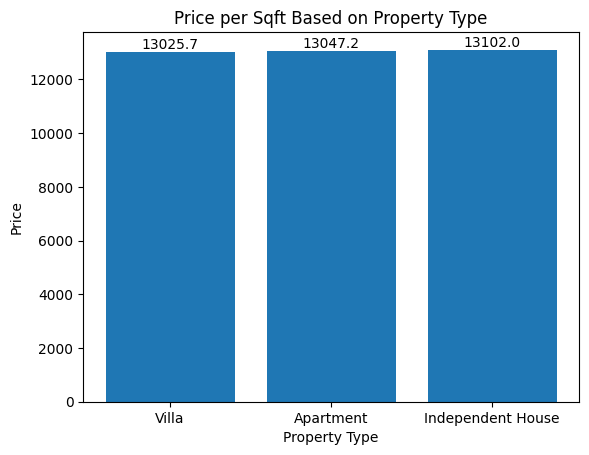

In [1866]:
# Visualization
plt.bar(price_per_sqft_on_type['Property_Type'], (price_per_sqft_on_type['mean']))

for index, value in zip(price_per_sqft_on_type['Property_Type'], (price_per_sqft_on_type['mean'])):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title("Price per Sqft Based on Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price")
plt.show()

### 1.4 Relationship between Property Size and Price

In [1867]:
size_price_df = df[['Size_in_SqFt', 'Price_in_Lakhs']]
size_price_df

,Size_in_SqFt,Price_in_Lakhs
0,4740,489.76
1,2364,195.52
2,3642,183.79
3,2741,300.29
4,4823,182.90
...,...,...
249995,1995,274.75
249996,2293,13.40
249997,2910,236.94
249998,1149,141.66


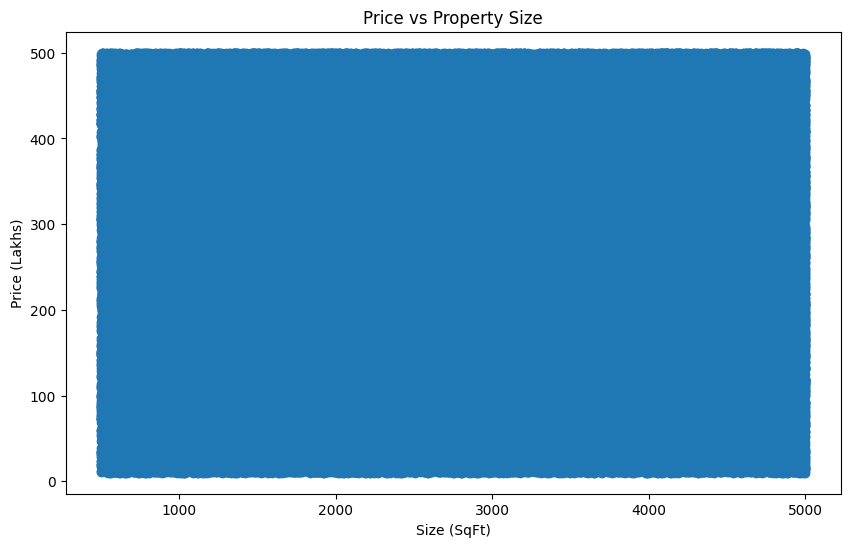

In [1868]:
# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(size_price_df['Size_in_SqFt'], size_price_df['Price_in_Lakhs'])

plt.xlabel('Size (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.title('Price vs Property Size')

plt.show()

In [1869]:
# Summary Statistics
bins = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000, np.inf]
labels = ['0 to 500', '500 to 1000', '1000 to 1500', '1500 to 2000', '2000 to 2500', '2500 to 3000', '3000 to 3500', '3500 to 4000', '4000 to 4500', '4500 to 5000', '5000 and above']
size_price_df['Size_Bucket'] = pd.cut(size_price_df['Size_in_SqFt'], bins=bins, labels=labels)
print("Summary on\nProperty Price(in Lakhs) Based on Size(in SqFt)")
price_based_on_size = size_price_df.groupby('Size_Bucket')['Price_in_Lakhs'].agg(['mean','median','count']).reset_index()
price_based_on_size

Summary on
Property Price(in Lakhs) Based on Size(in SqFt)


,Size_Bucket,mean,median,count
0,0 to 500,260.345088,268.150,57
1,500 to 1000,255.942204,257.540,27940
2,1000 to 1500,255.644476,254.745,27644
3,1500 to 2000,254.229250,253.870,27682
4,2000 to 2500,254.168149,254.165,27838
5,2500 to 3000,253.892024,252.925,27826
6,3000 to 3500,253.650536,251.815,27686
7,3500 to 4000,254.918367,254.265,27766
8,4000 to 4500,254.869355,252.580,27591
9,4500 to 5000,253.956874,252.760,27970


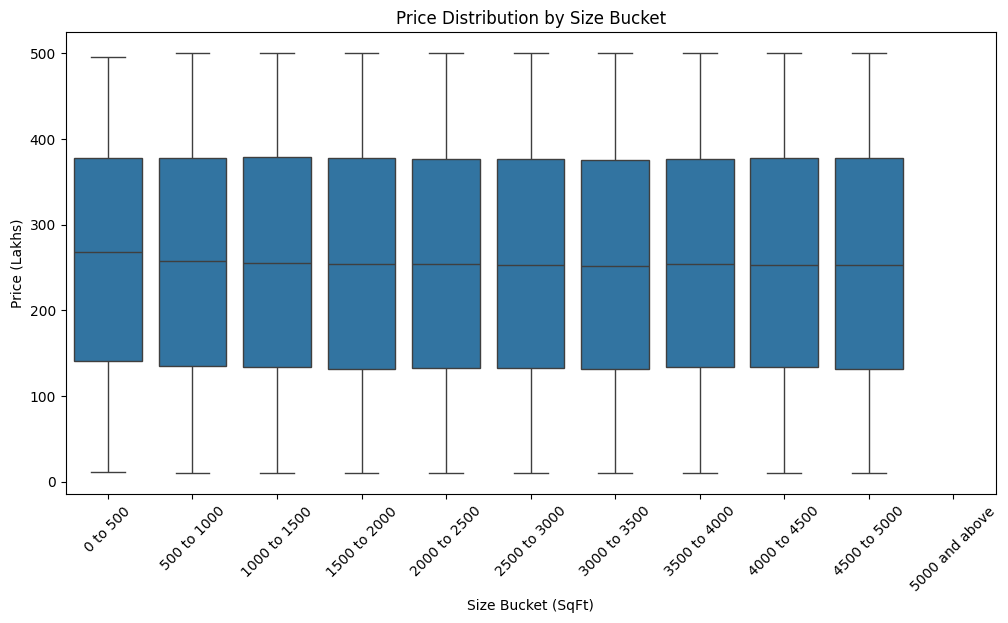

In [1870]:
# Visualization of Summary
plt.figure(figsize=(12, 6))
sns.boxplot(data=size_price_df, x='Size_Bucket', y='Price_in_Lakhs')

plt.xticks(rotation=45)
plt.xlabel('Size Bucket (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.title('Price Distribution by Size Bucket')

plt.show()

### 1.5 Outliers in Price per Sqft and Property Size

In [1871]:
df['Price_per_SqFt_in_Lakhs'].describe()

count    250000.000000
mean          0.130583
std           0.130719
min           0.002000
25%           0.048000
50%           0.092000
75%           0.160000
max           0.992000
Name: Price_per_SqFt_in_Lakhs, dtype: float64

The price difference between 75%ile of the properties and the property with the most price per sqft is **too large**. Let's visualize and see how much outliers are present in the dataset.

In [1872]:
# IQR
Q1 = df['Price_per_SqFt_in_Lakhs'].quantile(0.25)
Q3 = df['Price_per_SqFt_in_Lakhs'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Price_per_SqFt_in_Lakhs'] < lower_bound) | (df['Price_per_SqFt_in_Lakhs'] > upper_bound)]

print("Inter Quartile Range Calculation")
print(f"Q1 (25%ile): {Q1}")
print(f"Q3 (75%ile): {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Whisker: {lower_bound}")
print(f"Upper Whisker: {upper_bound}\n")
print(f"Unusual/Rare Price per SqFt (Outliers) Present in the dataset: {outliers.shape[0]} out of {df.shape[0]}")

Inter Quartile Range Calculation
Q1 (25%ile): 0.048
Q3 (75%ile): 0.16
IQR: 0.112
Lower Whisker: -0.12000000000000001
Upper Whisker: 0.328

Unusual/Rare Price per SqFt (Outliers) Present in the dataset: 19621 out of 250000


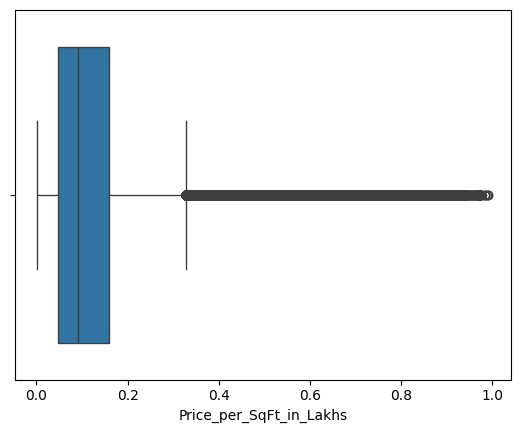

In [1873]:
# Outlier Visualization
sns.boxplot(x=df['Price_per_SqFt_in_Lakhs'])
plt.show()

Let's remove the rows with above the 99th quantile range, which indicated extreme outliers.

In [ ]:
# Removing extreme outliers
print(f"Total rows before removing: {df.shape[0]}")

upper = df["Price_per_SqFt_in_Lakhs"].quantile(0.99)
outlier_removed_count = df[df['Price_per_SqFt_in_Lakhs'] > upper].shape[0]
df = df[df['Price_per_SqFt_in_Lakhs'] <= upper]

print(f"Total rows after removing: {df.shape[0]}")
print(f"Remaining Outliers: {outliers.shape[0] - outlier_removed_count}")

Total rows before removing: 250000
Total rows after removing: 247504
Remaining Outliers: 17125


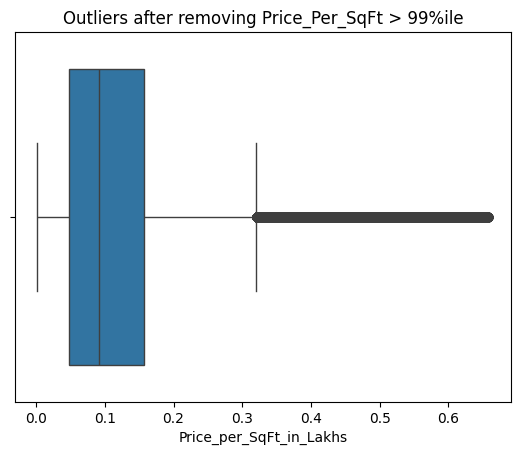

In [1875]:
# After Removing extreme outliers
sns.boxplot(x=df['Price_per_SqFt_in_Lakhs'])
plt.title("Outliers after removing Price_Per_SqFt > 99%ile")
plt.show()

In [1876]:
# Capping the outlier prices to upper bound limit
Q3 = df['Price_per_SqFt_in_Lakhs'].quantile(0.75)
upper_bound = Q3 + 1.5 * IQR
df['Price_in_Lakhs_Capped'] = df['Price_per_SqFt_in_Lakhs'].clip(upper=upper_bound)

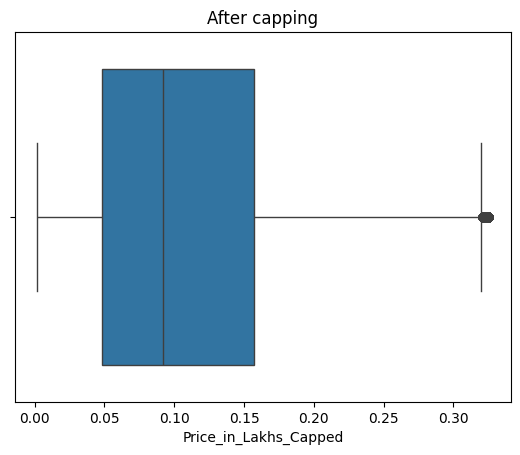

In [1877]:
# Outlier Visualization
sns.boxplot(x=df['Price_in_Lakhs_Capped'])
plt.title("After capping")
plt.show()